**Analisis Pasar Kerja Data Analyst**

Created by Aaliyah Afida Tzurraya

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving ds_salaries.csv to ds_salaries.csv


In [ ]:
df = pd.read_csv("ds_salaries.csv")

print("Dataset berhasil dibaca!")
print("Ukuran dataset:", df.shape)

df.head()

Dataset berhasil dibaca!
Ukuran dataset: (607, 12)


,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [ ]:
print("=== INFO DATASET ===")
df.info()

print("\n=== JUMLAH MISSING VALUE ===")
print(df.isnull().sum())

# Kolom Unnamed: 0 hanya nomor indeks, sehingga tidak ikut dibandingkan
kolom_data = df.columns.drop("Unnamed: 0", errors="ignore")

print("\n=== JUMLAH DATA DUPLIKAT ===")
print(df.duplicated(subset=kolom_data).sum())

print("\n=== STATISTIK NUMERIK ===")
display(df.describe())

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB

=== JUMLAH MISSING VALUE ===
Unnamed: 0            0
work_year             0
experience_level      0
employment_type       0
job_title             0
s

,Unnamed: 0,work_year,salary,salary_in_usd,remote_ratio
count,607.000000,607.000000,6.070000e+02,607.000000,607.00000
mean,303.000000,2021.405272,3.240001e+05,112297.869852,70.92257
std,175.370085,0.692133,1.544357e+06,70957.259411,40.70913
min,0.000000,2020.000000,4.000000e+03,2859.000000,0.00000
25%,151.500000,2021.000000,7.000000e+04,62726.000000,50.00000
50%,303.000000,2022.000000,1.150000e+05,101570.000000,100.00000
75%,454.500000,2022.000000,1.650000e+05,150000.000000,100.00000
max,606.000000,2022.000000,3.040000e+07,600000.000000,100.00000


In [ ]:
# Menghapus kolom indeks yang tidak berisi informasi analisis
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

# Memeriksa dan menghapus data duplikat berdasarkan kolom sebenarnya
jumlah_duplikat = df.duplicated().sum()
print("Jumlah data duplikat sebelum dihapus:", jumlah_duplikat)

df = df.drop_duplicates().reset_index(drop=True)
print("Ukuran data setelah duplikat dihapus:", df.shape)

# Mengambil pekerjaan yang mengandung "Data Analyst"
data_analyst = df[
    df["job_title"].str.contains("Data Analyst", case=False, na=False)
].copy()

print("Jumlah data Data Analyst:", len(data_analyst))

display(data_analyst.head())

Jumlah data duplikat sebelum dihapus: 42
Ukuran data setelah duplikat dihapus: (565, 11)
Jumlah data Data Analyst: 104


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
5,2020,EN,FT,Data Analyst,72000,USD,72000,US,100,US,L
8,2020,MI,FT,Business Data Analyst,135000,USD,135000,US,100,US,L
13,2020,MI,FT,Lead Data Analyst,87000,USD,87000,US,100,US,L
14,2020,MI,FT,Data Analyst,85000,USD,85000,US,100,US,L


**1. Analisis gaji Data Analyst**

In [ ]:
mean_salary = data_analyst["salary_in_usd"].mean()
median_salary = data_analyst["salary_in_usd"].median()
min_salary = data_analyst["salary_in_usd"].min()
max_salary = data_analyst["salary_in_usd"].max()

print("=== ANALISIS GAJI DATA ANALYST ===")
print(f"Rata-rata salary : ${mean_salary:,.2f}")
print(f"Median salary    : ${median_salary:,.2f}")
print(f"Salary terendah  : ${min_salary:,.2f}")
print(f"Salary tertinggi : ${max_salary:,.2f}")

=== ANALISIS GAJI DATA ANALYST ===
Rata-rata salary : $91,034.28
Median salary    : $87,827.00
Salary terendah  : $6,072.00
Salary tertinggi : $450,000.00


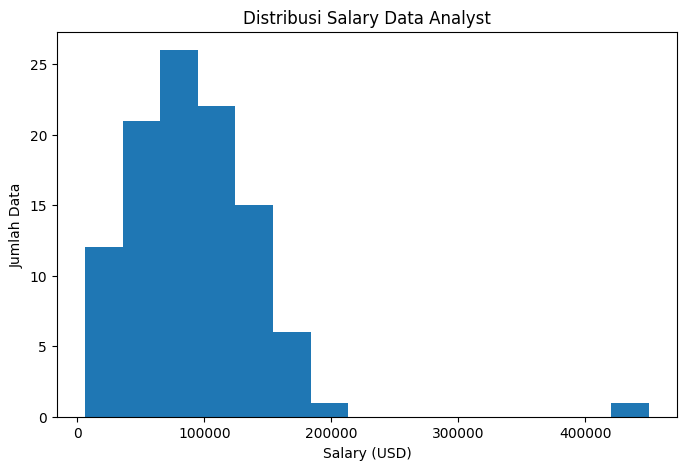

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(data_analyst["salary_in_usd"], bins=15)

plt.title("Distribusi Salary Data Analyst")
plt.xlabel("Salary (USD)")
plt.ylabel("Jumlah Data")

plt.show()

**2. Analisis berdasarkan experience level**

In [ ]:
experience_salary = (
    data_analyst
    .groupby("experience_level")["salary_in_usd"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

print("=== SALARY BERDASARKAN EXPERIENCE LEVEL ===")
display(experience_salary)

=== SALARY BERDASARKAN EXPERIENCE LEVEL ===


,count,mean,median
experience_level,,,
EX,3,130000.000000,130000.0
SE,44,112933.909091,111912.5
MI,40,78439.275000,68175.0
EN,17,57111.882353,59102.0


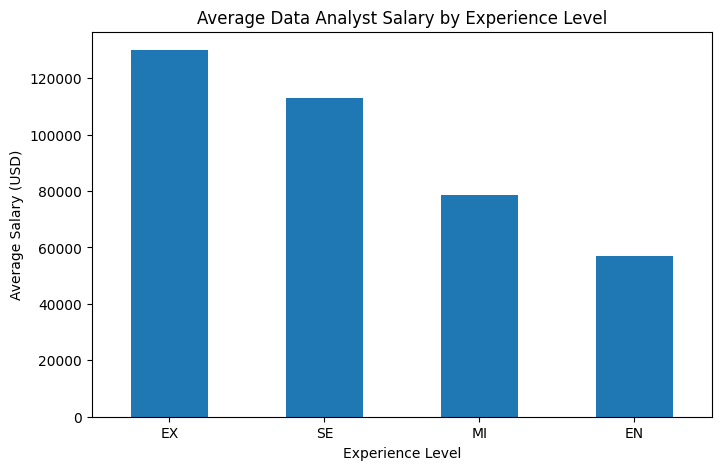

In [ ]:
experience_salary["mean"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Data Analyst Salary by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Average Salary (USD)")

plt.xticks(rotation=0)
plt.show()

**3. Analisis Employment Type**

In [ ]:
employment_salary = (
    data_analyst
    .groupby("employment_type")["salary_in_usd"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

print("=== SALARY BERDASARKAN EMPLOYMENT TYPE ===")
display(employment_salary)

=== SALARY BERDASARKAN EMPLOYMENT TYPE ===


,count,mean,median
employment_type,,,
CT,1,100000.000000,100000.0
FT,102,91737.362745,87827.0
PT,1,10354.000000,10354.0


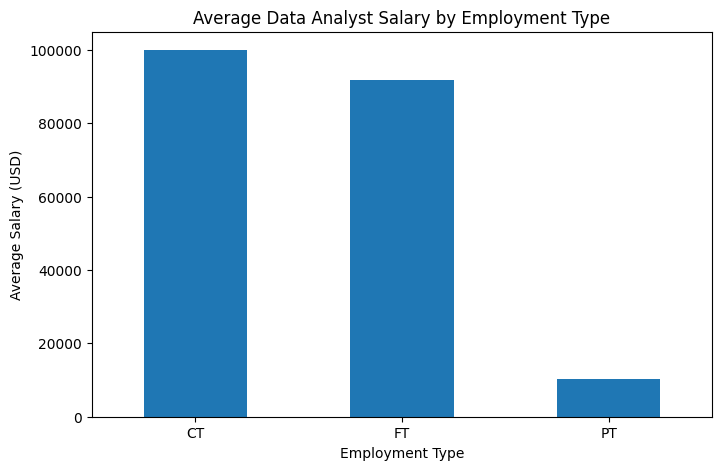

In [ ]:
employment_salary["mean"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Data Analyst Salary by Employment Type")
plt.xlabel("Employment Type")
plt.ylabel("Average Salary (USD)")

plt.xticks(rotation=0)
plt.show()

**4. Analisis remote work**

In [ ]:
def remote_category(x):
    if x == 0:
        return "On-site"
    elif x == 50:
        return "Hybrid"
    elif x == 100:
        return "Fully Remote"
    else:
        return "Other"

data_analyst["work_type"] = data_analyst["remote_ratio"].apply(remote_category)

remote_salary = (
    data_analyst
    .groupby("work_type")["salary_in_usd"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

print("=== SALARY BERDASARKAN WORK TYPE ===")
display(remote_salary)

=== SALARY BERDASARKAN WORK TYPE ===


,count,mean,median
work_type,,,
Fully Remote,72,98948.000000,93350.0
On-site,21,84746.523810,81666.0
Hybrid,11,51239.272727,55000.0


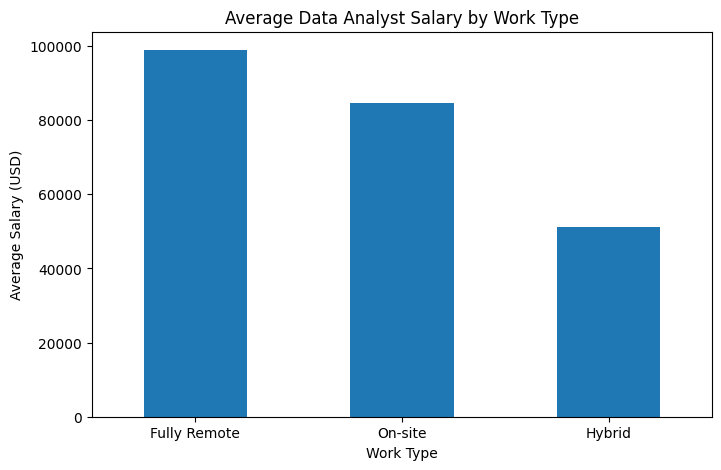

In [ ]:
remote_salary["mean"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Data Analyst Salary by Work Type")
plt.xlabel("Work Type")
plt.ylabel("Average Salary (USD)")

plt.xticks(rotation=0)
plt.show()

**5. Analisis median salary Data Analyst berdasarkan negara perusahaan**


In [ ]:
country_salary_all = (
    data_analyst
    .groupby("company_location")["salary_in_usd"]
    .agg(["count", "mean", "median"])
)

country_salary = (
    country_salary_all[country_salary_all["count"] >= 3]
    .sort_values("median", ascending=False)
)

print("=== MEDIAN SALARY DATA ANALYST BERDASARKAN NEGARA ===")
print("Negara yang ditampilkan memiliki minimal 3 observasi.")
display(country_salary)

=== MEDIAN SALARY DATA ANALYST BERDASARKAN NEGARA ===
Negara yang ditampilkan memiliki minimal 3 observasi.


,count,mean,median
company_location,,,
US,70,112344.914286,105630.0
CA,9,76444.222222,71786.0
GB,6,52712.333333,51935.0
ES,3,29098.000000,32974.0
GR,3,32313.333333,32974.0
IN,4,12548.750000,12257.0


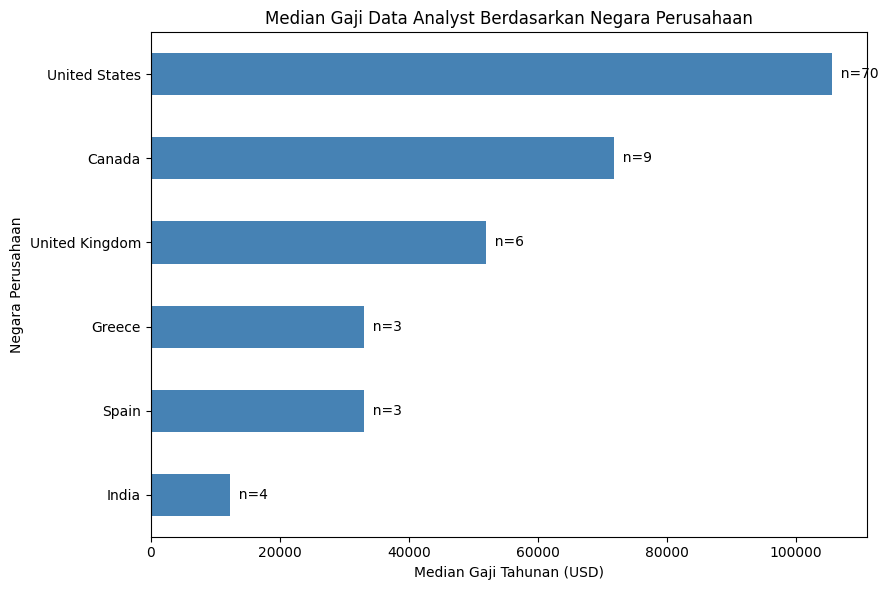

In [ ]:
country_names = {
    "US": "United States",
    "CA": "Canada",
    "GB": "United Kingdom",
    "ES": "Spain",
    "GR": "Greece",
    "IN": "India"
}

plot_country = country_salary.sort_values("median").copy()
plot_country.index = plot_country.index.map(
    lambda code: country_names.get(code, code)
)

ax = plot_country["median"].plot(
    kind="barh",
    figsize=(9, 6),
    color="steelblue"
)

plt.title("Median Gaji Data Analyst Berdasarkan Negara Perusahaan")
plt.xlabel("Median Gaji Tahunan (USD)")
plt.ylabel("Negara Perusahaan")

for bar, n in zip(ax.patches, plot_country["count"]):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"  n={int(n)}",
        va="center"
    )

plt.tight_layout()
plt.show()

**6. Job title Data Analyst yang paling banyak muncul**

In [ ]:
job_titles = data_analyst["job_title"].value_counts()

print("=== JOB TITLE DATA ANALYST ===")
display(job_titles)

=== JOB TITLE DATA ANALYST ===


,count
job_title,
Data Analyst,82
BI Data Analyst,6
Business Data Analyst,5
Lead Data Analyst,3
Product Data Analyst,2
Financial Data Analyst,2
Principal Data Analyst,2
Marketing Data Analyst,1
Finance Data Analyst,1


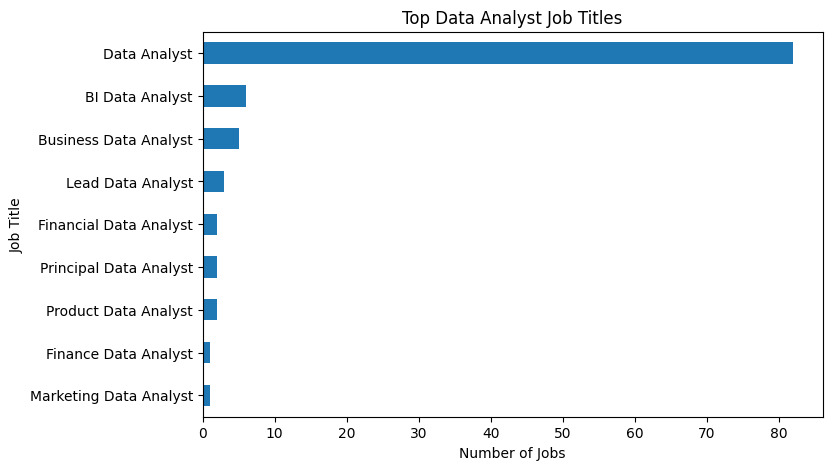

In [ ]:
job_titles.head(10).sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Top Data Analyst Job Titles")
plt.xlabel("Number of Jobs")
plt.ylabel("Job Title")

plt.show()

In [ ]:
data_analyst.to_csv(
    "data_analyst_clean.csv",
    index=False
)

print("File berhasil dibuat: data_analyst_clean.csv")

File berhasil dibuat: data_analyst_clean.csv


In [ ]:
files.download("data_analyst_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Interactive Dashboard

View the interactive Tableau dashboard here:  
[Data Analyst Salary Dashboard (2020–2022)](https://public.tableau.com/views/DataAnalystSalaryDashboard20202022/DataAnalystSalaryAnalysis20202022?:language=en-GB&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)

## Key Insights

1. **Overall Salary**  
   The average annual salary is USD 91,034, while the median salary is USD 87,827. The higher average indicates the presence of several high-salary observations.

2. **Experience Level**  
   Salaries generally increase with experience. Executive-level positions have the highest average salary, followed by senior-level positions.

3. **Employment Type**  
   Full-time positions dominate the dataset with 102 of 104 observations. Contract and part-time categories only contain one observation each.

4. **Work Type**  
   Remote positions have the highest average salary at USD 98,948, followed by on-site positions at USD 84,747 and hybrid positions at USD 51,239.

5. **Company Country**  
   Among countries with at least three observations, the United States has the highest median salary at USD 105,630.

6. **Job Title**  
   “Data Analyst” is the most frequently recorded job title, with 82 of 104 observations.

## Conclusion

Experience level, work arrangement, and company location are associated with Data Analyst salary differences. However, the findings are limited to 104 salary records from 2020–2022.